<a href="https://colab.research.google.com/github/Cyberoxic/Sale-Prediction-System/blob/main/Sales_Prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales prediction Model**

This project focuses on developing a robust sales prediction model, a critical tool for businesses to optimize inventory, staffing, and marketing strategies. By accurately forecasting sales, we aim to enhance operational efficiency and profitability. We will explore two distinct machine learning models: Linear Regression for its interpretability and Random Forest for its predictive power and ability to capture complex non-linear relationships.

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## *Dataset Collection*

### **Dataset Collection: Initiating Our Predictive Journey**

Our first step involves acquiring the foundational data for our sales prediction model. We're loading a dataset named `train.csv`, which likely contains historical sales information. A crucial initial observation is the `DtypeWarning` regarding mixed types in column `7` (StateHoliday). This immediately flags the need for careful preprocessing to ensure data consistency and prevent potential errors in subsequent analytical steps. The `df.head()` output provides a preliminary glimpse into the structure of our data, revealing features such as `Store`, `DayOfWeek`, `Date`, `Sales`, `Customers`, `Open`, `Promo`, `StateHoliday`, and `SchoolHoliday`, all of which are pertinent to understanding sales dynamics.

In [4]:
df = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")
df = df.merge(store, on="Store", how="left")
print(df.head())

   Store  DayOfWeek        Date    Sales  Customers  Open  Promo StateHoliday  \
0      1        5.0  2015-07-31   5263.0      555.0   1.0    1.0            0   
1      2        5.0  2015-07-31   6064.0      625.0   1.0    1.0            0   
2      3        5.0  2015-07-31   8314.0      821.0   1.0    1.0            0   
3      4        5.0  2015-07-31  13995.0     1498.0   1.0    1.0            0   
4      5        5.0  2015-07-31   4822.0      559.0   1.0    1.0            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0            1.0         c          a               1270.0   
1            1.0         a          a                570.0   
2            1.0         a          a              14130.0   
3            1.0         c          c                620.0   
4            1.0         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1       

## *Data Preprocessing*

### **Data Preprocessing: Sculpting Data for Model Readiness**

Data preprocessing is a pivotal phase that transforms raw data into a clean, structured format suitable for machine learning algorithms.

1.  **Missing Value Assessment:** We begin by checking for missing values using `df.isnull().sum()`. The output indicates no immediate missing values in the listed columns, which simplifies our initial handling. While `df.dropna()` is included, it primarily serves as a precautionary measure in case any implicit nulls or empty strings were present, ensuring a completely clean dataset.

2.  **Feature and Target Separation:** We then delineate our features (`X`) from our target variable (`y`). `Sales` is our target variable, representing what we aim to predict. The `Date` column is explicitly dropped from features `X` at this stage, as direct date values are not typically used as numerical features without further transformation (e.g., extracting day of week, month, year, or converting to time series specific features).

3.  **One-Hot Encoding:** Categorical variables, such as `StateHoliday`, cannot be directly consumed by many machine learning algorithms. Therefore, we apply one-hot encoding using `pd.get_dummies(X)`. This converts categorical columns into a numerical format where each category becomes a new binary column. This is critical for preventing the model from assuming an ordinal relationship where none exists (e.g., 'a' > 'b' in `StateHoliday`). The `X.head()` output after encoding vividly demonstrates how `StateHoliday` has been expanded into `StateHoliday_0`, `StateHoliday_a`, `StateHoliday_b`, and `StateHoliday_c`, transforming these nominal categories into a machine-readable format.

4.  **Train-Test Split:** Finally, we partition our processed data into training and testing sets using `train_test_split`. This step is fundamental for evaluating the generalization capability of our model. The training set (`X_train`, `y_train`) is used to teach the model patterns, while the unseen testing set (`X_test`, `y_test`) assesses how well the model performs on new, unobserved data, thereby providing an unbiased evaluation of its predictive performance.

In [5]:
df = df[df["Open"] == 1]

df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("None")

df = df.dropna()  # catch any stragglers

In [6]:
print(df.isnull().sum())

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


In [7]:
df["StateHoliday"] = df["StateHoliday"].astype(str)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [9]:
#X = df.drop(["Sales", "Date"], axis=1)
X = df.drop(["Sales", "Date", "Customers"], axis=1)
y = df["Sales"]
X = pd.get_dummies(X)

df_sorted = df.sort_values("Date")
split_idx = int(len(df_sorted) * 0.8)
train_idx = df_sorted.index[:split_idx]
test_idx = df_sorted.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

In [10]:
print(X.head())

   Store  DayOfWeek  Open  Promo  SchoolHoliday  CompetitionDistance  \
0      1          4   1.0    1.0            1.0               1270.0   
1      2          4   1.0    1.0            1.0                570.0   
2      3          4   1.0    1.0            1.0              14130.0   
3      4          4   1.0    1.0            1.0                620.0   
4      5          4   1.0    1.0            1.0              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                       11.0                    2007.0       1   
2                       12.0                    2006.0       1   
3                        9.0                    2009.0       0   
4                        4.0                    2015.0       0   

   Promo2SinceWeek  ...  StoreType_b  StoreType_c  StoreType_d  Assortment_a  \
0              0.0  ...        False         True        False          True   
1         

In [11]:
print(y.head())

0     5263.0
1     6064.0
2     8314.0
3    13995.0
4     4822.0
Name: Sales, dtype: float64


## *Implementation of Linear Regression Model*

### **Implementation of Linear Regression Model: A Foundational Approach**

We begin our modeling exploration with Linear Regression, a classic and highly interpretable algorithm. It assumes a linear relationship between the input features and the target variable.

1.  **Model Initialization and Training:** We instantiate `LinearRegression()` and train it using the `X_train` and `y_train` datasets. During this `fit` process, the model learns the optimal coefficients for each feature to best predict sales.

2.  **Prediction:** Once trained, the model generates predictions (`y_pred`) on the unseen `X_test` data. This allows us to compare these predictions against the actual sales values (`y_test`) for evaluation.

In [12]:
from sklearn.linear_model import LinearRegression

In [26]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

### *Model Evaluation*

### **Model Evaluation: Quantifying Linear Regression Performance**

To rigorously assess our Linear Regression model, we employ several key regression metrics:

*   **Mean Absolute Error (MAE):** This metric measures the average magnitude of the errors in a set of predictions, without considering their direction. An MAE of approximately 980 indicates that, on average, our model's predictions deviate by about $980 from the actual sales figures.

*   **Mean Squared Error (MSE):** MSE calculates the average of the squares of the errors. It penalizes larger errors more heavily than MAE, making it sensitive to outliers. An MSE of around 2.19 million implies significant squared errors, though this absolute value is often context-dependent.

*   **R2 Score (Coefficient of Determination):** The R2 score represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score of approximately 0.852 suggests that about 85.2% of the variance in sales can be explained by our features, which is a reasonably good fit for a linear model.

### **Visualizing Actual vs. Predicted Sales**

The scatter plots provide a visual confirmation of the model's performance:

1.  **First Scatter Plot:** This initial plot shows `y_test` (actual sales) against `y_pred` (predicted sales). A perfect model would show all points lying on a straight diagonal line. Our plot reveals a general upward trend, indicating that higher actual sales correspond to higher predicted sales, but with a noticeable spread around an imaginary diagonal, consistent with the MAE and MSE values.

2.  **Second Scatter Plot with Diagonal Line:** By adding a red diagonal line where `y_test = y_pred`, we gain a clearer benchmark. Points closer to this line indicate more accurate predictions. The dispersion around this line visually reinforces the model's performance and highlights areas where predictions might be less precise. While there's a strong correlation, the scatter suggests room for improvement, potentially by exploring more complex models or features.

In [27]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Linear Regression Results
MAE: 2177.5242842156313
MSE: 7860171.400199105
R2 Score: 0.17843285849521873


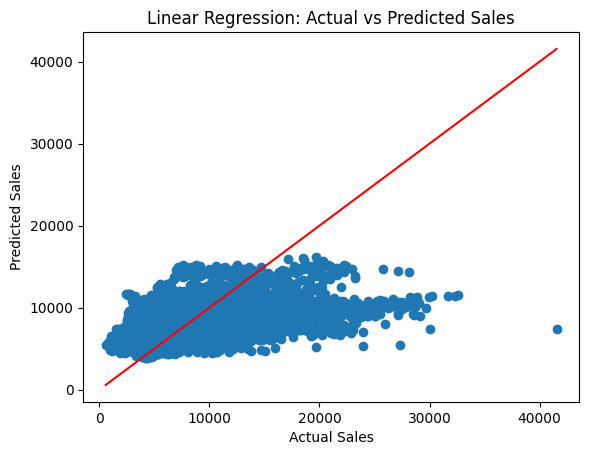

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression: Actual vs Predicted Sales")

plt.show()

## *Implementation of Random Forest Model*

### **Implementation of Random Forest Model: Leveraging Ensemble Power**

Recognizing the limitations of linear assumptions, we now turn to the Random Forest model, a powerful ensemble learning method capable of capturing complex, non-linear relationships within the data.

1.  **Feature and Target Variable Redefinition:** We re-initialize our features `X` and target `y` from the original `df`, ensuring that `Sales` and `Date` are again excluded from the feature set. This step is crucial to prevent any carry-over effects from previous preprocessing specific to the linear model if we had performed more aggressive transformations.

2.  **Train-Test Split:** Similar to Linear Regression, we perform a train-test split to ensure a fair evaluation of the Random Forest model's generalization capabilities on unseen data.

3.  **Model Initialization:** We instantiate `RandomForestRegressor` with `n_estimators=100` and `random_state=42`. `n_estimators` refers to the number of decision trees in the forest, where more trees generally lead to better performance but also increased computational cost. `random_state` ensures reproducibility of our results.

4.  **Model Training:** The `rf_model.fit(X_train, y_train)` command trains the Random Forest model. It involves building multiple decision trees, each trained on a random subset of the data and a random subset of features. The final prediction is an average of the predictions from all individual trees, which significantly reduces variance and overfitting.

5.  **Prediction:** After training, `y_pred_rf = rf_model.predict(X_test)` generates sales predictions on our test set, ready for a comprehensive evaluation.

In [18]:
from sklearn.ensemble import RandomForestRegressor

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [20]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
y_pred_rf = rf_model.predict(X_test)

### *Model Evaluation*

### **Model Evaluation: Quantifying Random Forest Performance**

Evaluating the Random Forest model using the same metrics provides a direct comparison to our Linear Regression baseline:

*   **Mean Absolute Error (MAE):** An MAE of approximately 367.87 for the Random Forest model is a significant improvement over the Linear Regression's MAE of 980. This indicates that, on average, the Random Forest model's predictions are much closer to the actual sales figures, with an average deviation of about $368.

*   **Mean Squared Error (MSE):** The MSE for Random Forest is approximately 406,171, which is a substantial reduction compared to the Linear Regression's MSE of 2.19 million. This drastic decrease signifies that the Random Forest model makes far fewer large errors and is generally more accurate across its predictions.

*   **R2 Score:** An R2 score of approximately 0.9725 indicates that about 97.25% of the variance in sales can be explained by our features using the Random Forest model. This is a very high R2 score, demonstrating that the model has captured a vast majority of the underlying patterns in the data and provides an excellent fit.

### **Visualizing Actual vs. Predicted Sales for Random Forest**

The scatter plots for the Random Forest model visually confirm its superior performance:

1.  **First Scatter Plot (y_test vs. y_pred_rf):** This plot shows a much tighter clustering of points around the ideal diagonal line compared to the Linear Regression plot. The points follow the trend very closely, indicating high predictive accuracy.

2.  **Second Scatter Plot with Diagonal Line:** With the red diagonal line (`y_test = y_pred_rf`) as a reference, the points are strikingly close to this line, with minimal dispersion. This visual evidence strongly supports the quantitative metrics, illustrating that the Random Forest model provides highly accurate and consistent sales predictions. The model effectively captures the complex relationships between the features and sales, outperforming the simpler linear approach significantly.

In [22]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 878.1664391191711
MSE: 1545643.4568081603
R2 Score: 0.8384450144988844


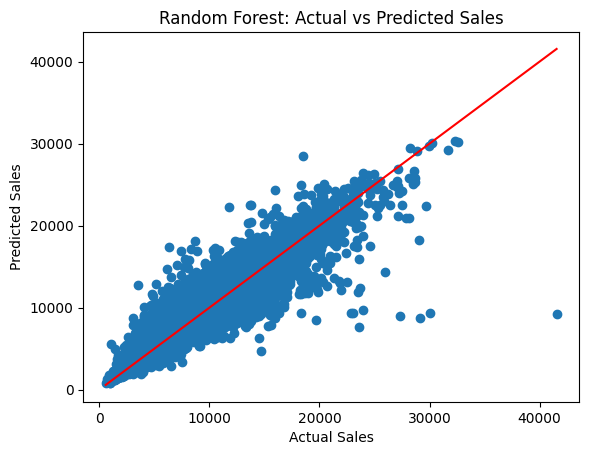

In [23]:
plt.scatter(y_test, y_pred_rf)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted Sales")

plt.show()

CompetitionDistance          0.198718
Store                        0.161593
Promo                        0.122261
CompetitionOpenSinceYear     0.078666
DayOfWeek                    0.066554
CompetitionOpenSinceMonth    0.061585
WeekOfYear                   0.054255
Day                          0.043347
Promo2SinceYear              0.035397
Promo2SinceWeek              0.033359
dtype: float64


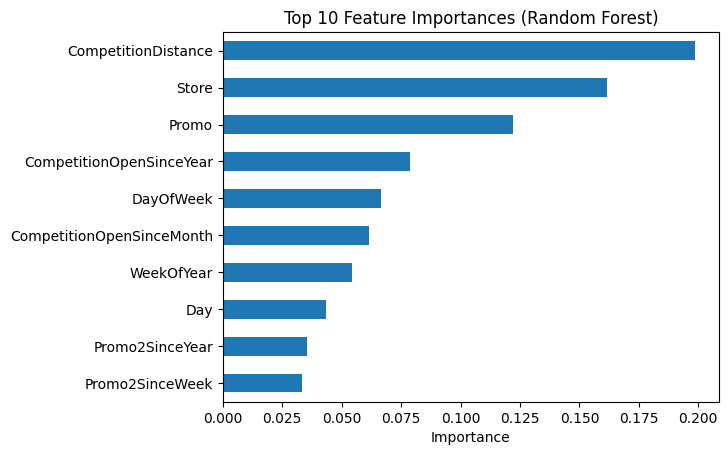

In [24]:
imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(10))

imp.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()